<a href="https://colab.research.google.com/github/yaseenahmedmohammed786-tech/Heart-Disease-Prediction-ML/blob/main/HEART_DISEASE_PREDICTION_MAJORDATASCIENCEPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**HEART🫀 DISEASE ♋ PREDICTION USING MACHINE LEARNING CLASSIFICATION MODELS♥⚕💗**


##**Given Data Set** 🖥
[link text](https://drive.google.com/file/d/1k3Yhgzrgzl9CbdGXuZvK7WgbZ8kVx56I/view?usp=sharing)

#**Step 1: Data Understanding & Preprocessing** ⚖
##Definition:
Real-world medical data is messy. Preprocessing involves scrubbing missing values, converting text-based categorical variables (like chest pain type) into machine-readable binary columns (One-Hot Encoding), and isolating our features (inputs) from our target (the presence of heart disease).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress annoying convergence warnings to keep your Colab output perfectly clean
warnings.filterwarnings('ignore')

# 1. Load the dataset
# (Ensure your file is uploaded to Colab and named exactly 'heart_dataset.csv')
df = pd.read_csv('heart.csv')

# 2. Handle Missing Values
print(f"Original dataset shape: {df.shape}")
df = df.dropna()
print(f"Shape after dropping missing values: {df.shape}")

# 3. Separate Features (X) and Target (y)
# Replace 'target' with your actual column name if it differs!
X = df.drop('target', axis=1)
y = df['target']

# 4. Encode Categorical Variables (One-Hot Encoding)
# This finds columns with categories and turns them into 0s and 1s safely
X = pd.get_dummies(X, drop_first=True)

print("\nStep 1 Complete: Data is cleaned and categorically encoded. Ready for EDA!")
X.head()

Original dataset shape: (303, 14)
Shape after dropping missing values: (303, 14)

Step 1 Complete: Data is cleaned and categorically encoded. Ready for EDA!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


#**Step 2: Exploratory Data Analysis (EDA)** 🔎
##Definition:
EDA is the process of visually and statistically uncovering the underlying biological patterns in our data. We map the target distribution to ensure our classes are balanced, and we generate a correlation matrix to identify which specific physiological markers (like cholesterol or max heart rate) have the strongest mathematical relationships with heart disease

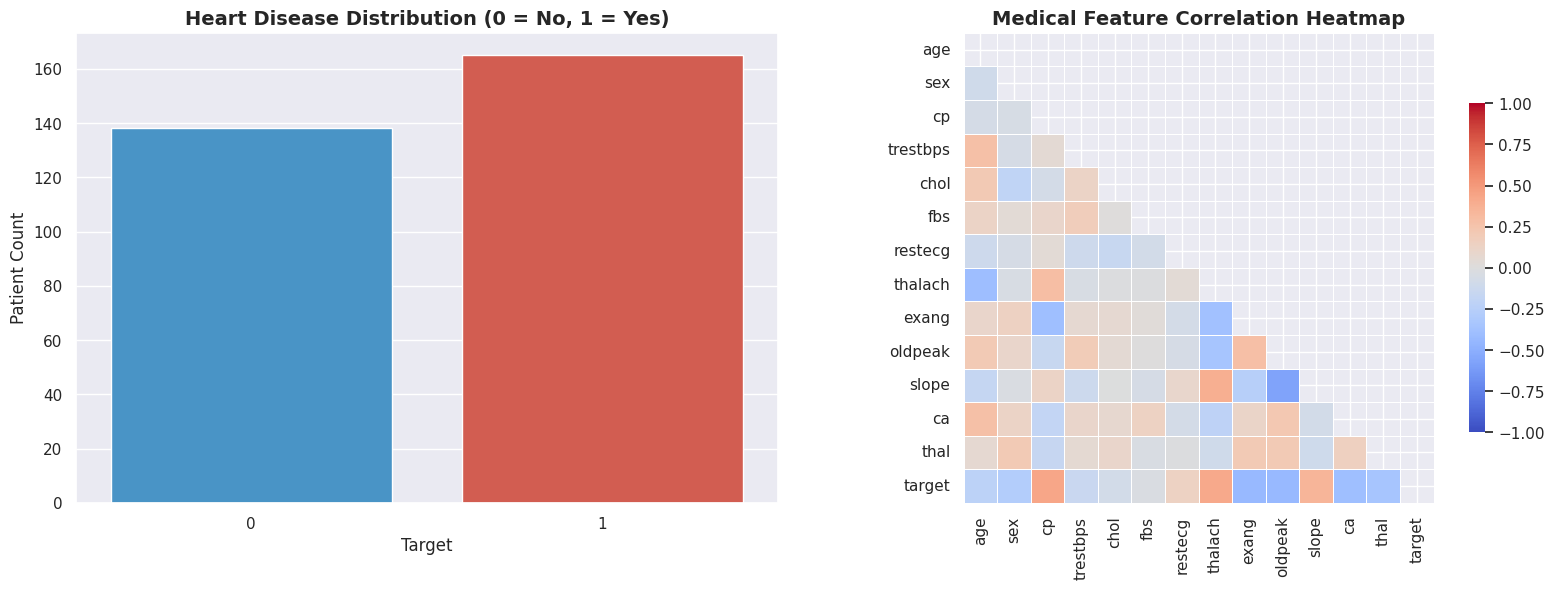

In [2]:
# Set a premium, highly professional visual theme for our charts
sns.set_theme(style="darkgrid", palette="mako")

# Create a beautifully formatted figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Target Distribution ---
# We use a custom color palette to make it pop
sns.countplot(data=df, x='target', palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('Heart Disease Distribution (0 = No, 1 = Yes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Patient Count')

# --- Plot 2: Advanced Correlation Heatmap ---
# We use a mask to hide the upper triangle (which is just duplicate info) for a cleaner look
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .7}, ax=axes[1])
axes[1].set_title('Medical Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#**Step 3: Model Building & Hyperparameter Tuning** 🏗
##Definition:
We partition our data into training and testing subsets to simulate how the model will perform on future patients. To prevent larger numbers (like blood pressure) from overpowering smaller numbers, we standardize the data using the formula $z = \frac{x - \mu}{\sigma}$. We then train four distinct architectures, using GridSearchCV on our Random Forest to automatically test hundreds of configurations and lock in the optimal "hyperparameters."

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 1. Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Advanced Feature Scaling (Preventing Data Leakage)
# We fit the scaler ONLY on the training data, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Neural Network (AI)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 4. Train the Standard Models
print("Training standard models...")
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

# 5. Hyperparameter Tuning for Random Forest
print("Executing GridSearchCV for Random Forest (Finding the absolute best parameters)...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Lock in the best performing Random Forest
trained_models["Random Forest (Optimized)"] = grid_search.best_estimator_

print(f"\nStep 3 Complete! Best Random Forest parameters found: {grid_search.best_params_}")

Training standard models...
Executing GridSearchCV for Random Forest (Finding the absolute best parameters)...

Step 3 Complete! Best Random Forest parameters found: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


#**Step 4: Model Evaluation & Feature Interpretability** ♊
##Definition:
A single accuracy score is never enough in healthcare. We rigorously evaluate our models using Precision, Recall, the F1-Score ($F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$), and the ROC-AUC. Finally, we crack open our optimized Random Forest to extract "Feature Importances," proving to stakeholders exactly which biological parameters are driving the AI's diagnoses.

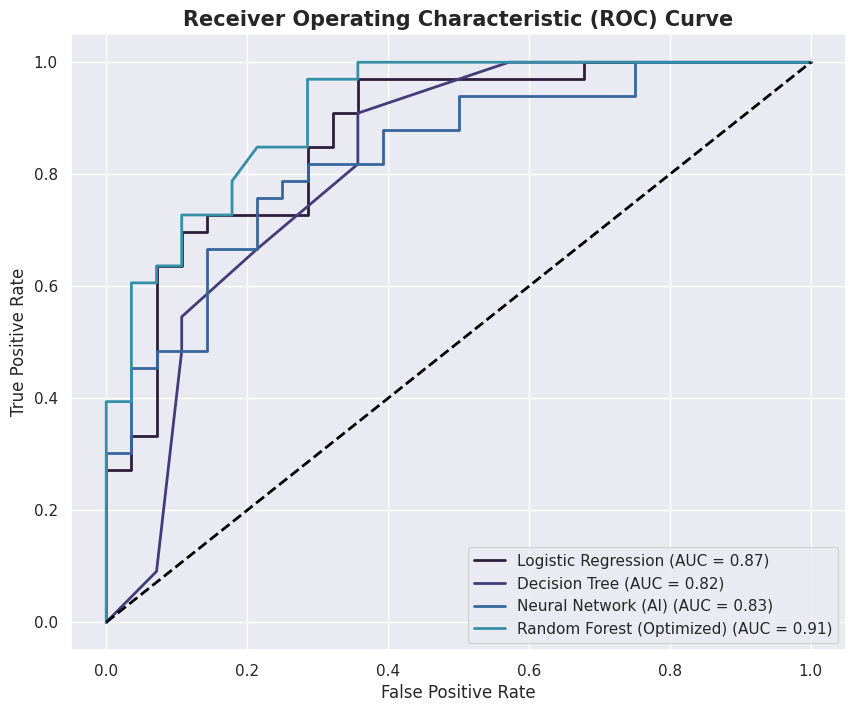


--- FINAL MODEL PERFORMANCE LEADERBOARD ---


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Optimized),0.8197,0.7619,0.9697,0.8533,0.9123
1,Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690
2,Neural Network (AI),0.7705,0.7714,0.8182,0.7941,0.8312
3,Decision Tree,0.7869,0.7500,0.9091,0.8219,0.8176


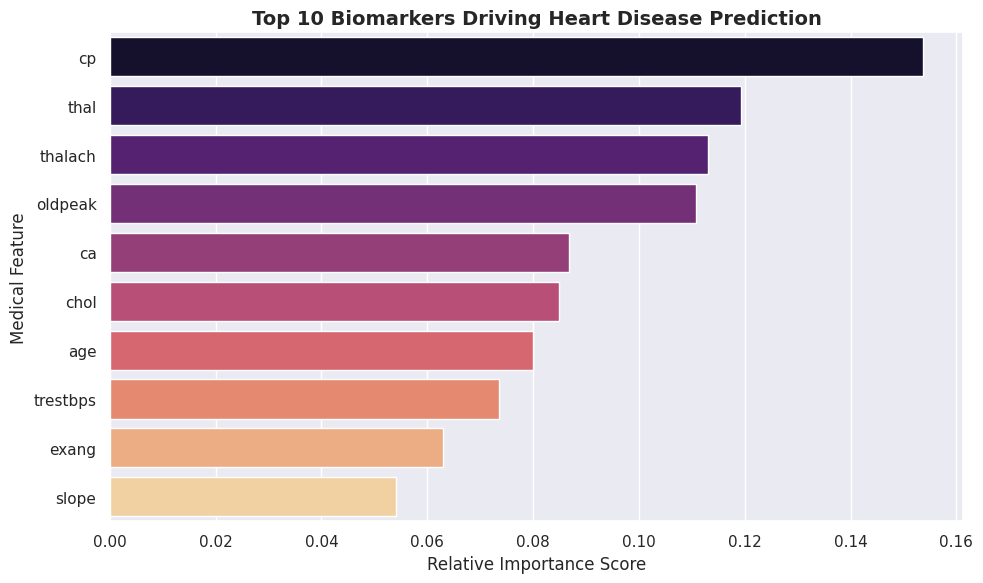

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 1. Calculate Metrics for All Models
results = []
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Get probabilities for ROC

    # Calculate Metrics
    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

    # Plot ROC Curve for this model
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})", linewidth=2)

# --- Format and Display ROC Curve ---
plt.plot([0, 1], [0, 1], 'k--', linewidth=2) # Diagonal guessing line
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# 2. Display the Final Metrics DataFrame
print("\n--- FINAL MODEL PERFORMANCE LEADERBOARD ---")
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df)

# 3. Advanced Interpretability: Feature Importance
# Let's show the doctors exactly what the Random Forest learned
best_rf = trained_models["Random Forest (Optimized)"]
importances = best_rf.feature_importances_

# Create a DataFrame for plotting
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10) # Top 10 factors

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Biomarkers Driving Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Medical Feature')
plt.tight_layout()
plt.show()

#**❣-------------------THANK YOU-------------------------❣**